# VLLM multi-GPU annotation (Mistral, 4 GPUs, parallel workers)

Optimisé pour l'utilisation de 4 GPUs, plusieurs workers et threads pour accélérer l'inférence sur un grand échantillon.

## 1) Runtime et configuration (multi-GPU, workers, threads)

In [1]:
import os
import json
import re
from pathlib import Path
import pandas as pd
from tqdm import tqdm
from vllm import LLM, SamplingParams

# 4 GPUs visibles, multiprocessing vLLM activé
os.environ["CUDA_VISIBLE_DEVICES"] = '0,1,2,3'
os.environ["VLLM_ENABLE_V1_MULTIPROCESSING"] = '1'
os.environ["MKL_THREADING_LAYER"] = 'GNU'
os.environ["MKL_SERVICE_FORCE_INTEL"] = '1'

conda_prefix = os.environ.get("CONDA_PREFIX", "")
if conda_prefix:
    conda_lib = f'{conda_prefix}/lib'
    ld_library_path = os.environ.get("LD_LIBRARY_PATH", "")
    ld_parts = [p for p in ld_library_path.split(":") if p]
    if conda_lib not in ld_parts:
        os.environ["LD_LIBRARY_PATH"] = f'{conda_lib}:{ld_library_path}' if ld_library_path else conda_lib

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = Path('/home/cbenavent/test/Arcom_rares')

DATASET_PATH = PROJECT_ROOT / 'data' / 'annotation_working_master_human_2100_seed.csv'
OUTPUT_DIR = PROJECT_ROOT / 'communication_function_outputs' / 'multi_gpu_vllm_test'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = 'mistralai/Mistral-7B-Instruct-v0.3'
MAX_NEW_TOKENS = 600
TENSOR_PARALLEL_SIZE = 4
VLLM_GPU_MEMORY_UTILIZATION = 0.40

print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATASET_PATH exists:', DATASET_PATH.exists())
print('Model:', MODEL_NAME)
print('TENSOR_PARALLEL_SIZE:', TENSOR_PARALLEL_SIZE)
print('CUDA_VISIBLE_DEVICES:', os.environ.get('CUDA_VISIBLE_DEVICES'))

try:
    import torch
    if torch.cuda.is_available():
        print('GPUs:', torch.cuda.device_count(), [torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())])
except Exception as exc:
    print('GPU check skipped:', exc)


/home/cbenavent/envs/vllm312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT: /home/cbenavent/test/Arcom_rares
DATASET_PATH exists: True
Model: mistralai/Mistral-7B-Instruct-v0.3
TENSOR_PARALLEL_SIZE: 4
CUDA_VISIBLE_DEVICES: 0,1,2,3
GPUs: 4 ['NVIDIA H100 NVL', 'NVIDIA H100 NVL', 'NVIDIA H100 NVL', 'NVIDIA H100 NVL']


In [2]:
# --- Prompt et parsing (identique à la version single-GPU) ---
RUBRIC_TEXT = """You score automotive ads on 3 dimensions (1 to 5):
- informativeness: factual, technical, concrete product information.
- expressiveness: emotion, desire, identity, style, aspiration.
- phatic: social bond, closeness, relationship-maintaining language.

Rules:
- Score each dimension independently from 1 to 5.
- If highest score is tied, dominant_dimension must be mixed.
- dominant_dimension_score must equal the highest score.
- Keep reason short and concrete.
"""

DIMENSIONS = ["informativeness", "expressiveness", "phatic"]
SCORE_MIN = 1
SCORE_MAX = 5

def output_schema_text() -> str:
    return """Return strict JSON only with:
{
  \"informativeness\": 1,
  \"expressiveness\": 1,
  \"phatic\": 1,
  \"dominant_dimension\": \"informativeness|expressiveness|phatic|mixed\",
  \"dominant_dimension_score\": 1,
  \"confidence\": 0.0,
  \"alternative_dimension\": \"informativeness|expressiveness|phatic|mixed|\",
  \"reason\": \"short explanation\"
}
"""

def build_prompt(visuel: str) -> str:
    clean_visuel = " ".join(str(visuel).split()).strip()
    return (
        f"{RUBRIC_TEXT}\n\n"
        f"{output_schema_text()}\n\n"
        "Ad to score:\n"
        f"Visuel: {clean_visuel}\n\n"
        "Return only strict JSON."
    )

def clamp_score(value, default=1):
    try:
        score = int(round(float(value)))
    except Exception:
        score = default
    return max(SCORE_MIN, min(SCORE_MAX, score))

def normalize_dimension_name(value):
    text = str(value or "").strip().lower()
    aliases = {
        "informative": "informativeness",
        "information": "informativeness",
        "referential": "informativeness",
        "expressive": "expressiveness",
        "emotive": "expressiveness",
        "emotion": "expressiveness",
        "phatique": "phatic",
    }
    text = aliases.get(text, text)
    return text if text in DIMENSIONS or text == "mixed" else ""

def extract_json_object(text: str) -> dict:
    fenced = re.search(r"```(?:json)?\s*(\{.*?\})\s*```", text, flags=re.DOTALL)
    candidates = [fenced.group(1)] if fenced else []
    candidates.append(text)
    decoder = json.JSONDecoder()
    for candidate in candidates:
        for match in re.finditer(r"\{", candidate):
            try:
                payload, _ = decoder.raw_decode(candidate[match.start():].strip())
                if isinstance(payload, dict):
                    return payload
            except json.JSONDecodeError:
                continue
    raise ValueError("Could not extract JSON from model output.")

def infer_scores_from_text(text: str) -> dict:
    labels = {
        "informativeness": ["informativeness", "informative", "referential", "information"],
        "expressiveness": ["expressiveness", "expressive", "emotive", "emotion"],
        "phatic": ["phatic", "phatique"],
    }
    compact = " ".join(str(text).split())
    extracted = {}
    for target, aliases in labels.items():
        score = None
        for alias in aliases:
            patterns = [
                rf"{alias}[^0-9]{{0,20}}([1-5])",
                rf"\"{alias}\"\s*:\s*([1-5])",
                rf"{alias}\s*=\s*([1-5])",
            ]
            for pattern in patterns:
                match = re.search(pattern, compact, flags=re.IGNORECASE)
                if match:
                    score = clamp_score(match.group(1))
                    break
            if score is not None:
                break
        extracted[target] = score if score is not None else 1
    return extracted

def coerce_prediction_dict(payload: dict, raw_text: str) -> dict:
    fallback_scores = infer_scores_from_text(raw_text)
    scores = {
        "informativeness": clamp_score(payload.get("informativeness", fallback_scores["informativeness"])),
        "expressiveness": clamp_score(payload.get("expressiveness", fallback_scores["expressiveness"])),
        "phatic": clamp_score(payload.get("phatic", fallback_scores["phatic"])),
    }
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    top_score = ranked[0][1]
    top_labels = [k for k, v in ranked if v == top_score]
    inferred_dom = "mixed" if len(top_labels) > 1 else top_labels[0]
    inferred_alt = ranked[1][0] if len(ranked) > 1 else ""
    dominant_dimension = normalize_dimension_name(payload.get("dominant_dimension")) or inferred_dom
    dominant_dimension_score = top_score
    alternative_dimension = normalize_dimension_name(payload.get("alternative_dimension")) or inferred_alt
    try:
        confidence = round(float(payload.get("confidence", 0.5)), 4)
    except Exception:
        confidence = 0.5
    confidence = max(0.0, min(1.0, confidence))
    reason = " ".join(str(payload.get("reason", "")).split()).strip()
    if not reason:
        reason = "parsed with fallback"
    return {
        "informativeness": scores["informativeness"],
        "expressiveness": scores["expressiveness"],
        "phatic": scores["phatic"],
        "dominant_dimension": dominant_dimension,
        "dominant_dimension_score": dominant_dimension_score,
        "confidence": confidence,
        "alternative_dimension": alternative_dimension,
        "reason": reason,
    }

def parse_model_prediction(raw_text: str):
    try:
        payload = extract_json_object(raw_text)
        prediction = coerce_prediction_dict(payload, raw_text)
        return prediction, True, ""
    except Exception as exc:
        prediction = coerce_prediction_dict({}, raw_text)
        return prediction, False, str(exc)


In [3]:
# --- Chargement et nettoyage — ensemble du fichier ---
df = pd.read_csv(DATASET_PATH)
if "Visuel" not in df.columns:
    raise ValueError("Column 'Visuel' not found in dataset.")

def clean_visuel_text(value: str) -> str:
    text = "" if pd.isna(value) else str(value)
    text = text.replace("\r", " ").replace("\n", " ").replace("\t", " ")
    text = re.sub(r"[\u200b\u200c\u200d\ufeff]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Toutes les lignes avec Visuel non-null
sample_df = df.loc[df["Visuel"].notna(), ["row_id", "Visuel"]].copy()
sample_df.rename(columns={"Visuel": "visuel"}, inplace=True)
sample_df["visuel"] = sample_df["visuel"].apply(clean_visuel_text)
print(f"Nombre de lignes à annoter : {len(sample_df)}")
sample_df.head()


Nombre de lignes à annoter : 8938


,row_id,visuel
0,0,"En caméra cachée, un homme invite des personne..."
1,1,Un homme recharge sa NISSAN LEAF et traverse u...
2,2,Des journalistes interrogent un homme qui vien...
3,3,Des journalistes interrogent un homme qui vien...
4,4,Des journalistes interrogent un homme qui vien...


In [4]:
# --- Helpers de generation ---
sampling_params = SamplingParams(
    temperature=0.0,
    max_tokens=MAX_NEW_TOKENS,
)

def default_prediction(reason: str, parse_ok: bool = False) -> dict:
    return {
        "prediction": {
            "informativeness": 1,
            "expressiveness": 1,
            "phatic": 1,
            "dominant_dimension": "mixed",
            "dominant_dimension_score": 1,
            "confidence": 0.0,
            "alternative_dimension": "",
            "reason": reason,
        },
        "parse_ok": parse_ok,
        "parse_error": "" if parse_ok else reason,
    }

In [5]:
# --- Inference : un seul LLM sur 4 GPUs, tous les prompts en un seul batch ---

def run_mistral_batch(sample: pd.DataFrame) -> list:
    """
    vLLM avec tensor_parallel_size=4 distribue nativement le modèle sur les 4 GPUs.
    Tous les prompts sont envoyés en un seul appel generate() : vLLM optimise
    le scheduling et le batching automatiquement — c'est l'approche la plus rapide.
    """
    llm = None
    rows = []
    try:
        llm = LLM(
            model=MODEL_NAME,
            tensor_parallel_size=TENSOR_PARALLEL_SIZE,
            trust_remote_code=True,
            gpu_memory_utilization=VLLM_GPU_MEMORY_UTILIZATION,
        )

        prompts = [build_prompt(v) for v in sample["visuel"].tolist()]
        print(f"Génération de {len(prompts)} réponses en batch (4 GPUs)...")

        try:
            outs = llm.generate(prompts, sampling_params, use_tqdm=True)
        except TypeError:
            outs = llm.generate(prompts, sampling_params)

        for in_row, out in zip(sample.itertuples(index=False), outs):
            raw_text = out.outputs[0].text if out.outputs else ""
            prediction, parse_ok, parse_error = parse_model_prediction(raw_text)
            rows.append({
                "row_id": int(getattr(in_row, "row_id")) if pd.notna(getattr(in_row, "row_id")) else None,
                "visuel": getattr(in_row, "visuel", ""),
                "model_name": MODEL_NAME,
                "raw_output": raw_text,
                "prediction": prediction,
                "parse_ok": parse_ok,
                "parse_error": parse_error,
            })

    except Exception as exc:
        error_text = f"LLM failed: {exc}"
        print(f"[ERROR] {error_text}")
        for in_row in sample.itertuples(index=False):
            rows.append({
                "row_id": int(getattr(in_row, "row_id")) if pd.notna(getattr(in_row, "row_id")) else None,
                "visuel": getattr(in_row, "visuel", ""),
                "model_name": MODEL_NAME,
                "raw_output": "",
                **default_prediction(reason=error_text, parse_ok=False),
            })
    finally:
        try:
            if llm is not None:
                del llm
            import gc; gc.collect()
            import torch
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                torch.cuda.ipc_collect()
        except Exception:
            pass

    return rows


In [6]:
# --- Execution et export — ensemble du fichier ---
import time

n = len(sample_df)
print(f"Running: {MODEL_NAME} (tensor_parallel_size={TENSOR_PARALLEL_SIZE}, n={n})")

perf_start_ts = time.perf_counter()
all_results = run_mistral_batch(sample_df)
perf_end_ts = time.perf_counter()

perf_total_seconds = max(0.0, perf_end_ts - perf_start_ts)
perf_items_per_second = (len(all_results) / perf_total_seconds) if perf_total_seconds > 0 else float("inf")

results_df = pd.DataFrame(all_results)

jsonl_path = OUTPUT_DIR / f"vllm_multi_gpu_predictions_full_{n}.jsonl"
csv_full_path = OUTPUT_DIR / f"vllm_multi_gpu_predictions_full_{n}_full.csv"
csv_scores_path = OUTPUT_DIR / f"vllm_multi_gpu_predictions_full_{n}_scores.csv"

with open(jsonl_path, "w", encoding="utf-8") as f:
    for item in all_results:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

flat_df = results_df.copy()
flat_df["prediction"] = flat_df["prediction"].apply(lambda x: json.dumps(x, ensure_ascii=False))
flat_df.to_csv(csv_full_path, index=False)

scores_df = pd.DataFrame([
    {
        "row_id": item.get("row_id"),
        "visuel": item.get("visuel", ""),
        "informativeness": (item.get("prediction") or {}).get("informativeness"),
        "expressiveness": (item.get("prediction") or {}).get("expressiveness"),
        "phatic": (item.get("prediction") or {}).get("phatic"),
        "model_name": item.get("model_name", ""),
    }
    for item in all_results
])
scores_df.to_csv(csv_scores_path, index=False)

print("Saved JSONL:", jsonl_path)
print("Saved full CSV:", csv_full_path)
print("Saved scores CSV:", csv_scores_path)
print(f"Inference time: {perf_total_seconds:.2f}s | Throughput: {perf_items_per_second:.2f} items/s")
scores_df.head(20)


Running: mistralai/Mistral-7B-Instruct-v0.3 (tensor_parallel_size=4, n=8938)
INFO 05-06 10:10:58 [utils.py:233] non-default args: {'trust_remote_code': True, 'tensor_parallel_size': 4, 'gpu_memory_utilization': 0.4, 'disable_log_stats': True, 'model': 'mistralai/Mistral-7B-Instruct-v0.3'}


INFO 05-06 10:10:59 [config.py:288] Inferred from consolidated*.safetensors files torch.bfloat16 dtype.
INFO 05-06 10:11:00 [model.py:549] Resolved architecture: MistralForCausalLM
INFO 05-06 10:11:00 [model.py:1678] Using max model len 32768
INFO 05-06 10:11:00 [scheduler.py:238] Chunked prefill is enabled with max_num_batched_tokens=16384.
INFO 05-06 10:11:00 [vllm.py:790] Asynchronous scheduling is enabled.
INFO 05-06 10:11:01 [compilation.py:292] Enabled custom fusions: allreduce_rms


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.
Multiple valid tokenizer files found. Using tokenizer.model.v3.


WARNING 05-06 10:11:02 [system_utils.py:152] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized
(EngineCore pid=694514) INFO 05-06 10:11:08 [core.py:105] Initializing a V1 LLM engine (v0.19.1) with config: model='mistralai/Mistral-7B-Instruct-v0.3', speculative_config=None, tokenizer='mistralai/Mistral-7B-Instruct-v0.3', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=32768, download_dir=None, load_format=auto, tensor_parallel_size=4, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, enable_return_routed_experts=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs

(Worker pid=694676) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
(Worker pid=694676) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.
(Worker pid=694677) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
(Worker pid=694677) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.
(Worker pid=694674) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and w

...

(EngineCore pid=694514) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
(EngineCore pid=694514) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.


(EngineCore pid=694514) INFO 05-06 10:12:06 [compilation.py:292] Enabled custom fusions: allreduce_rms
Génération de 8938 réponses en batch (4 GPUs)...


Processed prompts: 100%|██████████| 8938/8938 [00:45<00:00, 198.32it/s, est. speed input: 66935.13 toks/s, output: 27072.36 toks/s]


(EngineCore pid=694514) INFO 05-06 10:12:57 [core.py:1210] Shutdown initiated (timeout=0)
(EngineCore pid=694514) INFO 05-06 10:12:57 [core.py:1233] Shutdown complete
(Worker_TP1 pid=694675) (Worker_TP0 pid=694674) INFO 05-06 10:12:57 [multiproc_executor.py:764] Parent process exited, terminating worker queues
INFO 05-06 10:12:57 [multiproc_executor.py:859] WorkerProc shutting down.
(Worker_TP2 pid=694676) INFO 05-06 10:12:57 [multiproc_executor.py:859] WorkerProc shutting down.
(Worker_TP0 pid=694674) INFO 05-06 10:12:57 [multiproc_executor.py:859] WorkerProc shutting down.
(Worker_TP3 pid=694677) INFO 05-06 10:12:57 [multiproc_executor.py:859] WorkerProc shutting down.
Saved JSONL: /home/cbenavent/test/Arcom_rares/communication_function_outputs/multi_gpu_vllm_test/vllm_multi_gpu_predictions_full_8938.jsonl
Saved full CSV: /home/cbenavent/test/Arcom_rares/communication_function_outputs/multi_gpu_vllm_test/vllm_multi_gpu_predictions_full_8938_full.csv
Saved scores CSV: /home/cbenavent/

,row_id,visuel,informativeness,expressiveness,phatic,model_name
0,0,"En caméra cachée, un homme invite des personne...",1,1,1,mistralai/Mistral-7B-Instruct-v0.3
1,1,Un homme recharge sa NISSAN LEAF et traverse u...,1,1,1,mistralai/Mistral-7B-Instruct-v0.3
2,2,Des journalistes interrogent un homme qui vien...,1,2,1,mistralai/Mistral-7B-Instruct-v0.3
3,3,Des journalistes interrogent un homme qui vien...,1,2,1,mistralai/Mistral-7B-Instruct-v0.3
4,4,Des journalistes interrogent un homme qui vien...,1,2,1,mistralai/Mistral-7B-Instruct-v0.3
5,5,FORD B-MAX > Easy access**. **Portes arrière c...,5,1,1,mistralai/Mistral-7B-Instruct-v0.3
6,6,"Dans un restaurant, un homme et une femme inco...",1,1,1,mistralai/Mistral-7B-Instruct-v0.3
7,7,"Dans les gradins d'un court de tennis, une fem...",1,1,1,mistralai/Mistral-7B-Instruct-v0.3
8,8,Vision du monde en 2050 où les nouvelles techn...,1,2,1,mistralai/Mistral-7B-Instruct-v0.3
9,9,Vision du monde en 2050 où les nouvelles techn...,1,2,1,mistralai/Mistral-7B-Instruct-v0.3


In [7]:
# --- Performance summary + export CSV ---
# Requiert l'execution de la cellule precedente.

from datetime import datetime, timezone

if "all_results" not in globals() or "perf_total_seconds" not in globals():
    raise RuntimeError("Execute d'abord la cellule d'execution pour calculer les metriques de performance.")

n_items = len(all_results)
parse_ok_count = int(sum(1 for item in all_results if bool(item.get("parse_ok", False))))
parse_fail_count = n_items - parse_ok_count
parse_ok_rate = (parse_ok_count / n_items * 100.0) if n_items > 0 else 0.0
avg_latency_ms_per_item = (perf_total_seconds / n_items * 1000.0) if n_items > 0 else 0.0

run_ts_utc = datetime.now(timezone.utc).isoformat(timespec="seconds")

perf_row = {
    "run_ts_utc": run_ts_utc,
    "model_name": MODEL_NAME,
    "tensor_parallel_size": TENSOR_PARALLEL_SIZE,
    "items_processed": n_items,
    "total_time_seconds": round(perf_total_seconds, 3),
    "throughput_items_per_second": round(perf_items_per_second, 3),
    "avg_latency_ms_per_item": round(avg_latency_ms_per_item, 3),
    "parse_ok_count": parse_ok_count,
    "parse_fail_count": parse_fail_count,
    "parse_ok_rate_percent": round(parse_ok_rate, 2),
    "jsonl_path": str(jsonl_path) if "jsonl_path" in globals() else "",
    "csv_scores_path": str(csv_scores_path) if "csv_scores_path" in globals() else "",
}

perf_summary_df = pd.DataFrame([
    {"metric": "items_processed", "value": n_items},
    {"metric": "total_time_seconds", "value": round(perf_total_seconds, 3)},
    {"metric": "throughput_items_per_second", "value": round(perf_items_per_second, 3)},
    {"metric": "avg_latency_ms_per_item", "value": round(avg_latency_ms_per_item, 3)},
    {"metric": "parse_ok_count", "value": parse_ok_count},
    {"metric": "parse_fail_count", "value": parse_fail_count},
    {"metric": "parse_ok_rate_percent", "value": round(parse_ok_rate, 2)},
])

perf_run_df = pd.DataFrame([perf_row])
perf_latest_csv_path = OUTPUT_DIR / "vllm_multi_gpu_perf_latest.csv"
perf_history_csv_path = OUTPUT_DIR / "vllm_multi_gpu_perf_history.csv"

perf_run_df.to_csv(perf_latest_csv_path, index=False)

if perf_history_csv_path.exists():
    history_df = pd.read_csv(perf_history_csv_path)
    history_df = pd.concat([history_df, perf_run_df], ignore_index=True)
else:
    history_df = perf_run_df.copy()
history_df.to_csv(perf_history_csv_path, index=False)

print("Performance summary")
display(perf_summary_df)
print("Saved perf latest:", perf_latest_csv_path)
print("Saved perf history:", perf_history_csv_path)
display(history_df.tail(10))


Performance summary


,metric,value
0,items_processed,8938.000
1,total_time_seconds,124.261
2,throughput_items_per_second,71.929
3,avg_latency_ms_per_item,13.903
4,parse_ok_count,8938.000
5,parse_fail_count,0.000
6,parse_ok_rate_percent,100.000


Saved perf latest: /home/cbenavent/test/Arcom_rares/communication_function_outputs/multi_gpu_vllm_test/vllm_multi_gpu_perf_latest.csv
Saved perf history: /home/cbenavent/test/Arcom_rares/communication_function_outputs/multi_gpu_vllm_test/vllm_multi_gpu_perf_history.csv


,run_ts_utc,model_name,tensor_parallel_size,items_processed,total_time_seconds,throughput_items_per_second,avg_latency_ms_per_item,parse_ok_count,parse_fail_count,parse_ok_rate_percent,jsonl_path,csv_scores_path
0,2026-05-06T07:02:46+00:00,google/gemma-4-26B-A4B,4,20,219.905,0.091,10995.267,0,20,0.00,/home/cbenavent/test/Arcom_rares/communication...,/home/cbenavent/test/Arcom_rares/communication...
1,2026-05-06T07:06:12+00:00,google/gemma-4-26B-A4B,4,20,110.593,0.181,5529.633,0,20,0.00,/home/cbenavent/test/Arcom_rares/communication...,/home/cbenavent/test/Arcom_rares/communication...
2,2026-05-06T07:14:20+00:00,google/gemma-4-26B-A4B,4,20,99.267,0.201,4963.328,20,0,100.00,/home/cbenavent/test/Arcom_rares/communication...,/home/cbenavent/test/Arcom_rares/communication...
3,2026-05-06T07:17:30+00:00,google/gemma-4-26B-A4B,4,50,97.803,0.511,1956.052,50,0,100.00,/home/cbenavent/test/Arcom_rares/communication...,/home/cbenavent/test/Arcom_rares/communication...
4,2026-05-06T07:24:33+00:00,google/gemma-4-26B-A4B,4,8938,166.994,53.523,18.684,8937,1,99.99,/home/cbenavent/test/Arcom_rares/communication...,/home/cbenavent/test/Arcom_rares/communication...
5,2026-05-06T07:39:23+00:00,google/gemma-4-26B-A4B,4,8938,167.720,53.291,18.765,8936,2,99.98,/home/cbenavent/test/Arcom_rares/communication...,/home/cbenavent/test/Arcom_rares/communication...
6,2026-05-06T08:13:03+00:00,mistralai/Mistral-7B-Instruct-v0.3,4,8938,124.261,71.929,13.903,8938,0,100.00,/home/cbenavent/test/Arcom_rares/communication...,/home/cbenavent/test/Arcom_rares/communication...


## 7) Histogrammes des scores

Visualisation de la distribution des scores `informativeness`, `expressiveness` et `phaticness`.

Saved histogram plot: /home/cbenavent/test/Arcom_rares/latex/scores_hist_8938.png


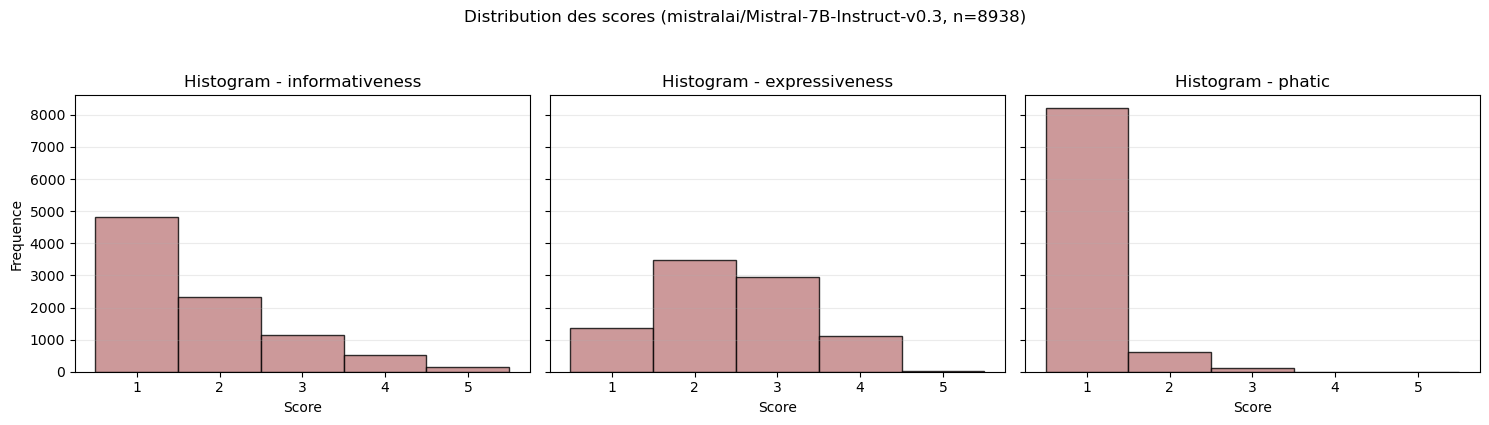

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

if "scores_df" not in globals() or scores_df.empty:
    scores_df = pd.read_csv(csv_scores_path)

score_cols = ["informativeness", "expressiveness", "phatic"]
plot_df = scores_df.copy()
for col in score_cols:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
for ax, col in zip(axes, score_cols):
    values = plot_df[col].dropna()
    ax.hist(values, bins=bins, edgecolor="black", alpha=0.8, color="#C08081")
    ax.set_title(f"Histogram - {col}")
    ax.set_xlabel("Score")
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.grid(axis="y", alpha=0.25)
axes[0].set_ylabel("Frequence")
fig.suptitle(f"Distribution des scores ({MODEL_NAME}, n={len(plot_df)})", y=1.05)

hist_plot_path = PROJECT_ROOT / "latex" / "scores_hist_8938.png"
fig.savefig(hist_plot_path, dpi=200, bbox_inches="tight")
print("Saved histogram plot:", hist_plot_path)

plt.tight_layout()
plt.show()

## 8) Matrice de corrélation des scores

Calcul de la corrélation de Pearson entre `informativeness`, `expressiveness` et `phatic`.

Correlation matrix (Pearson):


,informativeness,expressiveness,phatic
informativeness,1.000,-0.087,0.003
expressiveness,-0.087,1.000,0.203
phatic,0.003,0.203,1.000


Saved correlation plot: /home/cbenavent/test/Arcom_rares/latex/scores_corr_8938.png


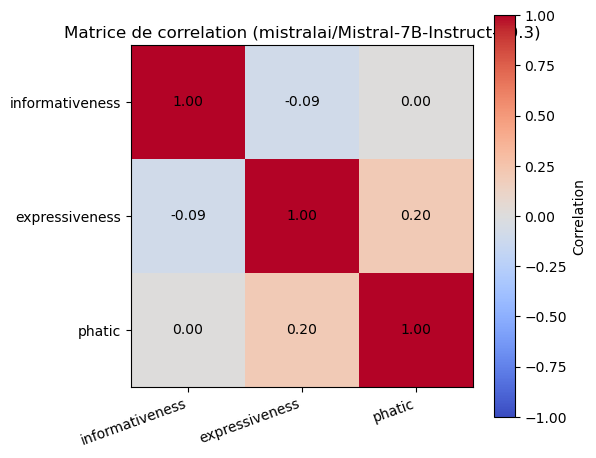

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

if "plot_df" in globals() and not plot_df.empty:
    corr_source = plot_df.copy()
elif "scores_df" in globals() and not scores_df.empty:
    corr_source = scores_df.copy()
else:
    corr_source = pd.read_csv(csv_scores_path)

score_cols = ["informativeness", "expressiveness", "phatic"]
for col in score_cols:
    corr_source[col] = pd.to_numeric(corr_source[col], errors="coerce")

corr_df = corr_source[score_cols].corr(method="pearson")
print("Correlation matrix (Pearson):")
display(corr_df.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_df.values, cmap="coolwarm", vmin=-1, vmax=1)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Correlation")
ax.set_xticks(np.arange(len(score_cols)))
ax.set_yticks(np.arange(len(score_cols)))
ax.set_xticklabels(score_cols, rotation=20, ha="right")
ax.set_yticklabels(score_cols)
ax.set_title(f"Matrice de correlation ({MODEL_NAME})")
for i in range(len(score_cols)):
    for j in range(len(score_cols)):
        value = corr_df.values[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="black")

corr_plot_path = PROJECT_ROOT / "latex" / "scores_corr_8938.png"
fig.savefig(corr_plot_path, dpi=200, bbox_inches="tight")
print("Saved correlation plot:", corr_plot_path)

plt.tight_layout()
plt.show()

## 9) Evolution annuelle des scores

Section dédiée à l'évolution temporelle des trois dimensions `informativeness`, `expressiveness` et `phatic`.

Le graphe ci-dessous compare les scores moyens année par année sur l'ensemble des publicités annotées. L'échelle verticale est resserrée sur l'intervalle `1-3` pour mieux faire apparaître les écarts entre séries.

,year,informativeness,expressiveness,phatic
0,2014,1.605519,1.995130,1.040584
1,2015,1.736742,2.426136,1.119318
2,2016,1.898161,2.391796,1.159830
3,2017,1.867756,2.598811,1.087667
4,2018,1.675862,2.555862,1.051034
5,2019,1.704670,2.376374,1.133242
6,2020,1.845884,2.197898,1.113835
7,2021,1.843687,2.498998,1.082164
8,2022,1.762876,2.462446,1.110515
9,2023,1.683853,2.533921,1.102442


Saved yearly trend plot: /home/cbenavent/test/Arcom_rares/latex/scores_trend_yearly_8938.png


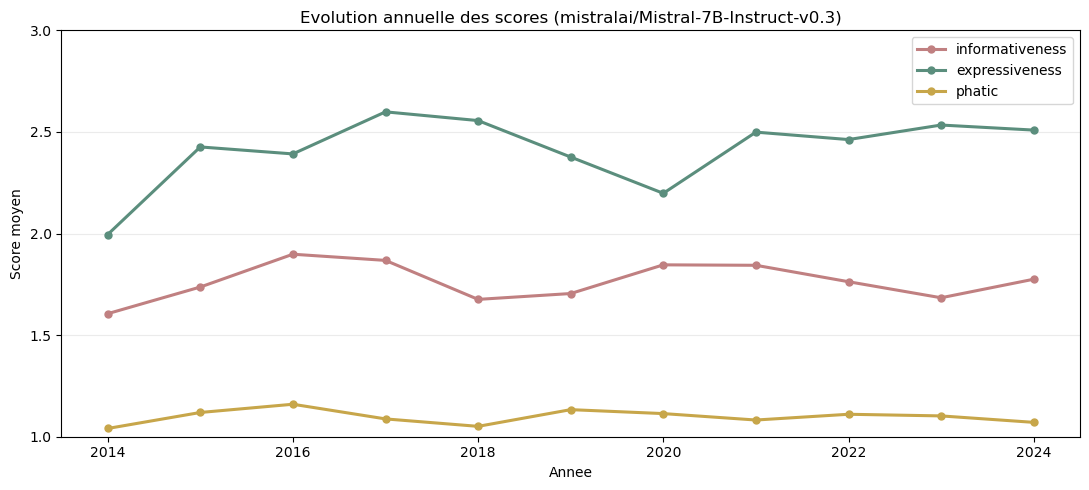

In [10]:
# --- Evolution annuelle des scores ---
import matplotlib.pyplot as plt
import pandas as pd

if "scores_df" not in globals() or scores_df.empty:
    scores_df = pd.read_csv(csv_scores_path)

if "df" not in globals() or df.empty:
    df = pd.read_csv(DATASET_PATH)

year_source = df.loc[:, ["row_id", "year"]].copy()
year_source["year"] = pd.to_numeric(year_source["year"], errors="coerce")

yearly_scores_df = scores_df.merge(year_source, on="row_id", how="left")
score_cols = ["informativeness", "expressiveness", "phatic"]
for col in score_cols:
    yearly_scores_df[col] = pd.to_numeric(yearly_scores_df[col], errors="coerce")

yearly_scores_df = yearly_scores_df.dropna(subset=["year"])
yearly_scores_df["year"] = yearly_scores_df["year"].astype(int)

yearly_trends_df = (
    yearly_scores_df
    .groupby("year", as_index=False)[score_cols]
    .mean()
    .sort_values("year")
)

display(yearly_trends_df.head(20))

fig, ax = plt.subplots(figsize=(11, 5))
colors = {
    "informativeness": "#C08081",
    "expressiveness": "#5B8E7D",
    "phatic": "#C7A64A",
}

for col in score_cols:
    ax.plot(
        yearly_trends_df["year"],
        yearly_trends_df[col],
        marker="o",
        linewidth=2.2,
        markersize=5,
        label=col,
        color=colors[col],
    )

ax.set_title(f"Evolution annuelle des scores ({MODEL_NAME})")
ax.set_xlabel("Annee")
ax.set_ylabel("Score moyen")
ax.set_ylim(1, 3)
ax.set_yticks([1.0, 1.5, 2.0, 2.5, 3.0])
ax.grid(True, axis="y", alpha=0.25)
ax.legend()

trend_plot_path = PROJECT_ROOT / "latex" / "scores_trend_yearly_8938.png"
fig.savefig(trend_plot_path, dpi=200, bbox_inches="tight")
print("Saved yearly trend plot:", trend_plot_path)

plt.tight_layout()
plt.show()

## 10) Comparaison des scores pour les 10 marques les plus fréquentes

Section dédiée à la comparaison des scores moyens `informativeness`, `expressiveness` et `phatic` pour les 10 marques les plus représentées dans le corpus annoté.

Le graphe ci-dessous compare les moyennes par marque avec une échelle verticale resserrée sur l'intervalle `1-3`.

,Marque,informativeness,expressiveness,phatic
4,RENAULT,2.022989,2.298851,1.163793
2,FIAT 500,1.941818,2.098182,1.225455
0,CITROEN C3,1.510204,2.551020,1.012245
3,PEUGEOT 208,1.348837,2.106977,1.120930
8,TOYOTA YARIS,1.661458,2.432292,1.031250
9,VW,1.284153,1.950820,1.142077
6,RENAULT MEGANE,1.987654,2.672840,1.086420
5,RENAULT CLIO,1.254902,2.915033,1.013072
7,RENAULT ZOE,1.864865,2.277027,1.128378
1,DACIA SANDERO,1.431655,2.107914,1.000000


Saved top brands plot: /home/cbenavent/test/Arcom_rares/latex/scores_top_brands_8938.png


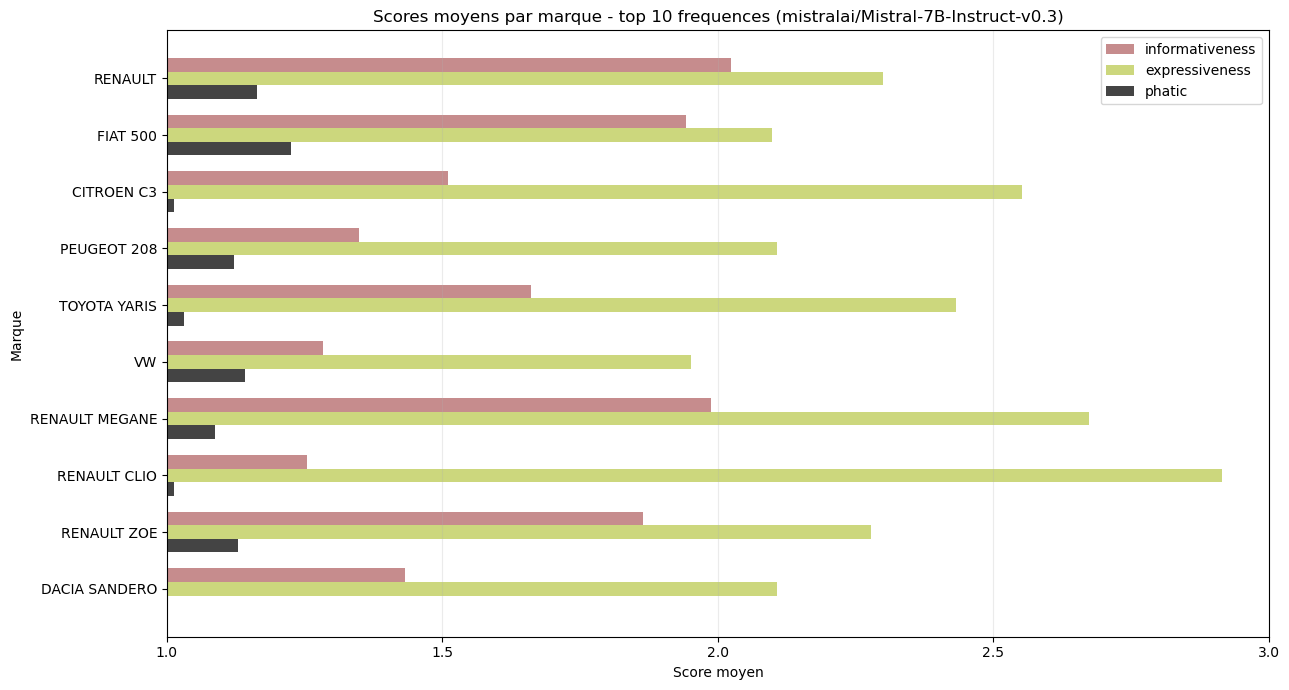

In [11]:
# --- Comparaison des scores pour les 10 marques les plus frequentes ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if "scores_df" not in globals() or scores_df.empty:
    scores_df = pd.read_csv(csv_scores_path)

if "df" not in globals() or df.empty:
    df = pd.read_csv(DATASET_PATH)

brand_source = df.loc[:, ["row_id", "Marque"]].copy()
brand_source["Marque"] = brand_source["Marque"].astype(str).str.strip()
brand_source.loc[brand_source["Marque"].isin(["", "nan", "None"]), "Marque"] = pd.NA

brand_scores_df = scores_df.merge(brand_source, on="row_id", how="left")
score_cols = ["informativeness", "expressiveness", "phatic"]
for col in score_cols:
    brand_scores_df[col] = pd.to_numeric(brand_scores_df[col], errors="coerce")

brand_scores_df = brand_scores_df.dropna(subset=["Marque"])
top_brands = brand_scores_df["Marque"].value_counts().head(10).index.tolist()
brand_scores_df = brand_scores_df[brand_scores_df["Marque"].isin(top_brands)].copy()

brand_trends_df = (
    brand_scores_df
    .groupby("Marque", as_index=False)[score_cols]
    .mean()
)
brand_trends_df["brand_rank"] = pd.Categorical(brand_trends_df["Marque"], categories=top_brands, ordered=True)
brand_trends_df = brand_trends_df.sort_values("brand_rank").drop(columns=["brand_rank"])

display(brand_trends_df)

fig, ax = plt.subplots(figsize=(13, 7))
colors = {
    "informativeness": "#C08081",
    "expressiveness": "#C7D36F",
    "phatic": "#2F2F2F",
}

y = np.arange(len(brand_trends_df))
bar_height = 0.24
offsets = {
    "informativeness": -bar_height,
    "expressiveness": 0.0,
    "phatic": bar_height,
}

for col in score_cols:
    ax.barh(
        y + offsets[col],
        brand_trends_df[col],
        height=bar_height,
        label=col,
        color=colors[col],
        alpha=0.9,
    )

ax.set_title(f"Scores moyens par marque - top 10 frequences ({MODEL_NAME})")
ax.set_xlabel("Score moyen")
ax.set_ylabel("Marque")
ax.set_xlim(1, 3)
ax.set_xticks([1.0, 1.5, 2.0, 2.5, 3.0])
ax.set_yticks(y)
ax.set_yticklabels(brand_trends_df["Marque"])
ax.grid(True, axis="x", alpha=0.25)
ax.legend()
ax.invert_yaxis()

brand_plot_path = PROJECT_ROOT / "latex" / "scores_top_brands_8938.png"
fig.savefig(brand_plot_path, dpi=200, bbox_inches="tight")
print("Saved top brands plot:", brand_plot_path)

plt.tight_layout()
plt.show()